<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_25_13_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error

from sklearn.metrics import roc_auc_score

#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.discrete.discrete_model import MNLogit

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier


from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Time Series Components

## Definition
A time series is a sequence of observations recorded over time at regular intervals.

Examples:
- Daily stock prices
- Monthly sales
- Annual population data
- Hourly temperature readings

---

# Components of Time Series

A time series consists of four major components:

1. Trend (T)
2. Seasonal Variation (S)
3. Cyclical Variation (C)
4. Random Variation (R)

Mathematical Representation:

Y(t) = T + S + C + R

where:
- Y(t) = Observed value
- T = Trend
- S = Seasonal component
- C = Cyclical component
- R = Random component

---

## 1. Trend (T)

### Definition
Trend represents the long-term movement of data over time.

### Types
- Upward Trend
- Downward Trend
- No Trend

### Example

Year | Sales
---- | -----
2020 | 100
2021 | 120
2022 | 140
2023 | 170
2024 | 200

Observation:
Sales are increasing over time, indicating an upward trend.

### Characteristics
- Long-term direction
- Smooth movement
- Does not repeat periodically

---

## 2. Seasonal Variation (S)

### Definition
Seasonal variation refers to patterns that repeat at fixed intervals.

### Examples
- Ice cream sales increase during summer.
- Retail sales increase during festival seasons.
- Electricity usage increases during winter or summer.

### Characteristics
- Fixed and predictable pattern
- Repeats every day, week, month, quarter, or year

### Example

Month | Sales
----- | -----
Jan | 100
Feb | 110
Mar | 120
Apr | 150
May | 180
Jun | 200

The same pattern repeats every year.

---

## 3. Cyclical Variation (C)

### Definition
Cyclical variation represents fluctuations occurring over long periods due to economic or business cycles.

### Stages
1. Expansion
2. Peak
3. Recession
4. Recovery

### Examples
- Economic boom and recession
- Housing market cycles
- Business growth cycles

### Characteristics
- No fixed time interval
- Lasts several years
- Difficult to predict exactly

### Difference from Seasonality

Seasonal Variation:
- Fixed interval
- Short-term repetition

Cyclical Variation:
- No fixed interval
- Long-term fluctuations

---

## 4. Random Variation (R)

### Definition
Random variation consists of irregular and unpredictable changes.

### Causes
- Natural disasters
- Pandemics
- Strikes
- Accidents
- Sudden policy changes

### Characteristics
- Unpredictable
- Non-repeating
- Cannot be modeled easily

### Example

Expected Sales = 150

Actual Sales after disaster = 90

The sudden drop is due to random variation.

---

# Summary Table

Component | Meaning | Repeats? | Example
--------- | ------- | -------- | -------
Trend | Long-term movement | No | Sales growth
Seasonal | Fixed periodic pattern | Yes | Festival sales
Cyclical | Economic/business cycle | No fixed interval | Recession
Random | Unpredictable fluctuation | No | Pandemic impact

---

# Key Points

- Trend shows overall direction.
- Seasonal variation repeats at fixed intervals.
- Cyclical variation occurs over long periods without a fixed pattern.
- Random variation is irregular and unpredictable.
- Understanding these components helps in forecasting future values.

# Forecast Error Metrics

Forecast error metrics are used to evaluate how well a prediction model performs by comparing actual values with predicted values.

---

## Sample Data

| Actual | Predicted | Error | Absolute Error | Absolute Percentage Error (%) | Squared Error |
|----------|----------|----------|----------|----------|----------|
| 7 | 9 | -2 | 2 | 28.6 | 4 |
| 6 | 7 | -1 | 1 | 16.7 | 1 |
| 8 | 6 | 2 | 2 | 25.0 | 4 |
| 4 | 9 | -5 | 5 | 125.0 | 25 |
| 6 | 8 | -2 | 2 | 33.3 | 4 |
| 7 | 5 | 2 | 2 | 28.6 | 4 |
| 8 | 7 | 1 | 1 | 12.5 | 1 |
| 7 | 6 | 1 | 1 | 14.3 | 1 |
| 9 | 9 | 0 | 0 | 0.0 | 0 |
| 6 | 8 | -2 | 2 | 33.3 | 4 |

---

# 1. Mean Error (ME)

### Definition
Mean Error measures the average forecasting error and indicates whether predictions are generally overestimating or underestimating actual values.

### Formula

\[
ME = \frac{\sum (Actual - Predicted)}{n}
\]

### Calculation

\[
ME = \frac{-6}{10}
\]

\[
ME = -0.6
\]

### Interpretation
- ME > 0 : Model tends to underestimate.
- ME < 0 : Model tends to overestimate.
- ME = 0 : No overall bias.

**Result:** ME = -0.6

---

# 2. Mean Absolute Error (MAE)

### Definition
MAE measures the average magnitude of errors without considering their direction.

### Formula

\[
MAE = \frac{\sum |Actual - Predicted|}{n}
\]

### Calculation

\[
MAE = \frac{18}{10}
\]

\[
MAE = 1.8
\]

### Interpretation
Lower MAE indicates better forecasting accuracy.

**Result:** MAE = 1.8

---

# 3. Mean Absolute Percentage Error (MAPE)

### Definition
MAPE expresses forecasting error as a percentage of the actual value.

### Formula

\[
MAPE = \frac{100}{n}
\sum
\left|
\frac{Actual - Predicted}{Actual}
\right|
\]

### Calculation

Average Percentage Error:

\[
\frac{28.6+16.7+25+125+33.3+28.6+12.5+14.3+0+33.3}{10}
\]

\[
MAPE = 31.73\%
\]

### Interpretation
- Lower MAPE indicates better predictions.
- Easy to understand because it is expressed in percentage form.

**Result:** MAPE = 31.73%

---

# 4. Mean Squared Error (MSE)

### Definition
MSE measures the average of squared forecasting errors.

### Formula

\[
MSE = \frac{\sum (Actual - Predicted)^2}{n}
\]

### Calculation

Sum of Squared Errors:

\[
4+1+4+25+4+4+1+1+0+4 = 48
\]

\[
MSE = \frac{48}{10}
\]

\[
MSE = 4.8
\]

### Interpretation
- Larger errors receive higher penalties because errors are squared.
- Widely used in machine learning and forecasting models.

**Result:** MSE = 4.8

---

# Summary Table

| Metric | Formula | Result |
|----------|----------|----------|
| Mean Error (ME) | Σ Error / n | -0.6 |
| Mean Absolute Error (MAE) | Σ Absolute Error / n | 1.8 |
| Mean Absolute Percentage Error (MAPE) | Σ Percentage Error / n | 31.73% |
| Mean Squared Error (MSE) | Σ Squared Error / n | 4.8 |

---

# Key Points

- **ME** measures forecast bias.
- **MAE** measures average error magnitude.
- **MAPE** measures percentage forecasting error.
- **MSE** penalizes large errors more heavily.
- Lower MAE, MAPE, and MSE indicate better model performance.

In [163]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt

In [164]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='birth')
df.head(2)

,BirthRate
0,26.663
1,23.598


<Axes: >

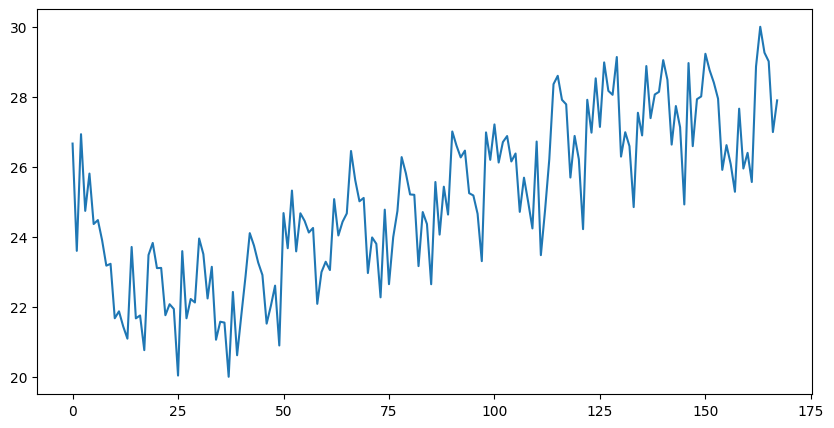

In [165]:
df.BirthRate.plot(figsize=(10,5)) # plotting the time series

In [166]:
from statsmodels.tsa.seasonal import seasonal_decompose as ssd

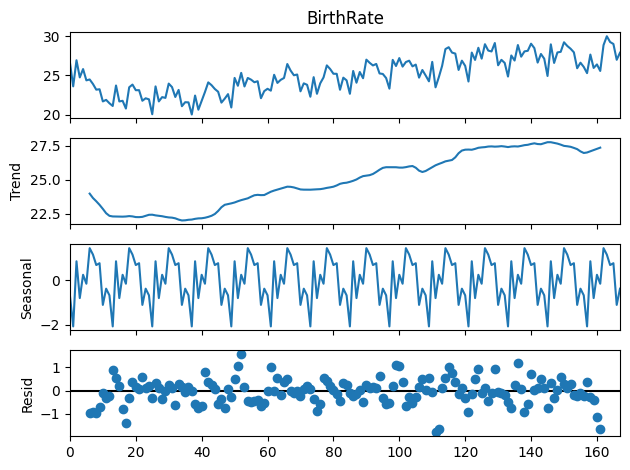

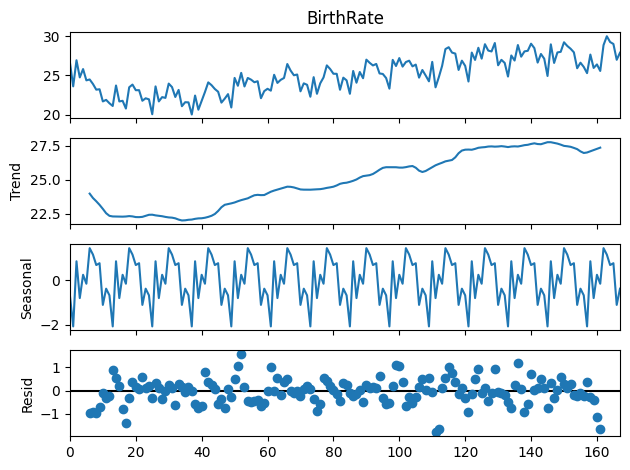

In [167]:
ssd(df.BirthRate, period=12).plot()

In [168]:
df_train = df.iloc[:144]  # training dataset for training the models
df_test = df.iloc[144:]    # test dataset for calculating rmse based on the predictions

In [169]:
df_train.shape

(144, 1)

In [170]:
df_test.shape

(24, 1)

## 🔰Naive Method🔰

In [171]:
df_test['naive'] = df_train.BirthRate.iloc[-1]
# np.float64(27.735)

In [172]:
sqrt(mean_squared_error(df_test.BirthRate, df_test.naive))

1.4277309211939526

#
#
#


## 🔰Simple Average Method🔰

In [173]:
df_test['SimpAvg'] = df_train.BirthRate.mean()   # np.float64(24.656833333333335)
sqrt(mean_squared_error(df_test.BirthRate, df_test.SimpAvg))


3.147657647627305

In [174]:
df_train.BirthRate.iloc[-12:]

#      BirthRate
# 132	26.589
# 133	24.848
# 134	27.543
# 135	26.896
# 136	28.878
# 137	27.390
# 138	28.065
# 139	28.141
# 140	29.048
# 141	28.484
# 142	26.634
# 143	27.735


df_train.BirthRate.iloc[-12:].mean()
# np.float64(27.52091666666667)

np.float64(27.52091666666667)

### ⚪12 Months Moving Average⚪

In [175]:
df_test['12Mths_Moving_Avg'] = df_train.BirthRate.iloc[-12:].mean()  # np.float64(27.52091666666667)
sqrt(mean_squared_error(df_test.BirthRate, df_test['12Mths_Moving_Avg']))

1.4044810849760687

### 🔶24 Months Moving Average🔶

In [176]:
df_test['24Mths_Moving_Avg'] = df_train.BirthRate.iloc[-24:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['24Mths_Moving_Avg']))

1.4038687245726835

# Weighted Mean (Weighted Average)

## Definition

A **Weighted Mean** is an average in which each value contributes according to its assigned weight.

It is used when some observations are more important than others.

---

## Formula

$$
\text{Weighted Mean}
=
\frac{\sum (\text{Value} \times \text{Weight})}
{\sum \text{Weight}}
$$

---

## Given Data

| Value (x) | Weight (w) | x × w |
|------------|------------|--------|
| 19 | 2 | 38 |
| 17 | 3 | 51 |
| 28 | 4 | 112 |
| 25 | 6 | 150 |
| 36 | 8 | 288 |
| 16 | 10 | 160 |
| **Total** | **33** | **799** |

---

## Step 1: Calculate Value × Weight

$$
19 \times 2 = 38
$$

$$
17 \times 3 = 51
$$

$$
28 \times 4 = 112
$$

$$
25 \times 6 = 150
$$

$$
36 \times 8 = 288
$$

$$
16 \times 10 = 160
$$

Total:

$$
\sum (xw) = 799
$$

---

## Step 2: Calculate Total Weight

$$
\sum w = 2 + 3 + 4 + 6 + 8 + 10
$$

$$
\sum w = 33
$$

---

## Step 3: Calculate Weighted Mean

$$
\text{Weighted Mean}
=
\frac{799}{33}
$$

$$
= 24.21
$$

---

## Result

$$
\boxed{\text{Weighted Mean} = 24.21}
$$

---

## Interpretation

- The weighted average of the given values is **24.21**.
- Values with higher weights have a greater influence on the final average.
- Here, the value **16** has the highest weight (10), so it strongly affects the weighted mean.

---

## Python Code

```python
values = [19, 17, 28, 25, 36, 16]
weights = [2, 3, 4, 6, 8, 10]

weighted_mean = sum(v*w for v, w in zip(values, weights)) / sum(weights)

print("Weighted Mean =", weighted_mean)
```

### Output

```python
Weighted Mean = 24.21212121212121
```

In [177]:
wts = np.arange(12,0,-1)
wts

array([12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1])

In [178]:
df_test['WMA'] = (sum(df_train.BirthRate.iloc[-12:]*wts))/sum(wts)
sqrt(mean_squared_error(df_test.BirthRate, df_test['WMA']))

1.4238115558763185

# Simple Exponential Smoothing (SES)

## Definition

**Simple Exponential Smoothing (SES)** is a forecasting technique used for time series data that has **no trend and no seasonality**.

It gives more weight to recent observations and less weight to older observations.

---

## Formula

$$
F_{t+1} = \alpha A_t + (1-\alpha)F_t
$$

Where:

- $F_{t+1}$ = Forecast for next period
- $A_t$ = Actual value at time $t$
- $F_t$ = Forecast at time $t$
- $\alpha$ = Smoothing constant $(0 < \alpha < 1)$

---

## Given Data

Assume:

$$
\alpha = 0.8
$$

Initial Forecast:

$$
F_1 = 7
$$

| Actual ($A_t$) | Forecast ($F_t$) |
|---------------|---------------|
| 7 | 7.0 |
| 6 | 7.0 |
| 8 | 6.2 |
| 5 | 7.6 |
| 9 | 5.5 |
| 7 | 8.3 |
| 5 | 7.3 |
| 7 | 5.5 |
| 6 | 6.7 |
| 8 | 6.1 |
| 9 | 7.6 |
| 4 | 8.7 |
| 6 | 4.9 |
| 5 | 5.8 |
| 6 | 5.2 |

---

## Example Calculation

### Forecast for Period 3

Using:

$$
F_{3} = \alpha A_2 + (1-\alpha)F_2
$$

$$
F_{3} = (0.8)(6) + (0.2)(7)
$$

$$
F_{3} = 4.8 + 1.4
$$

$$
F_{3} = 6.2
$$

---

### Forecast for Period 4

$$
F_{4} = (0.8)(8) + (0.2)(6.2)
$$

$$
F_{4} = 6.4 + 1.24
$$

$$
F_{4} = 7.64 \approx 7.6
$$

---

### Excel Formula

If:

- Actual value is in cell **A35**
- Previous forecast is in cell **B35**
- Alpha = 0.8

Then:

```excel
=A35*0.8 + B35*0.2
```

---

## Advantages

- Simple and easy to implement.
- Requires little storage.
- Gives higher importance to recent observations.
- Suitable for short-term forecasting.

---

## Limitations

- Does not handle trend.
- Does not handle seasonality.
- Accuracy depends on the choice of $\alpha$.

---

## Key Points

- Used when data has **no trend** and **no seasonal pattern**.
- Recent observations receive higher weights.
- Forecast equation:

$$
F_{t+1} = \alpha A_t + (1-\alpha)F_t
$$

- In this example:

$$
\alpha = 0.8
$$

meaning **80% weight is given to the latest observation and 20% to the previous forecast**.

In [179]:
x1 = np.array([7, 6, 8, 5, 9, 7, 5, 7, 6, 8, 9, 4, 6, 5, 6])
x1

from statsmodels.tsa.api import SimpleExpSmoothing

mod1 = SimpleExpSmoothing(x1).fit(smoothing_level=0.8, optimized=False)

mod1.forecast(1)

array([5.83156084])

### 🔶Simple Exponential Smoothing🔶

In [180]:
mod1 = SimpleExpSmoothing(df_train.BirthRate).fit(smoothing_level=0.8, optimized=False)
df_test['SES'] = mod1.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.SES))

1.4086237555629835

# 🔰Holt's linear trend method🔰 (No seasonal Variations)

In [181]:
from statsmodels.tsa.api import Holt

mod2 = Holt(df_train.BirthRate).fit(smoothing_level = 0.8)

In [182]:
df_test['HoltLinear'] = mod2.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test['HoltLinear']))

1.500895536001304

# 🔰Holt's Winter  method🔰
- used when we have trend and seasonaal variations

In [183]:
from statsmodels.tsa.api import ExponentialSmoothing
mod3 = ExponentialSmoothing(df_train.BirthRate,seasonal_periods=12).fit()
df_test['HoltWinter'] = mod3.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.HoltWinter))
# 1.420764

1.4207646015778608



# 🔰 ARIMA Model 🔰

*(AutoRegressive Integrated Moving Average)*

* This model should be used when we have a **stationary time series**.
* For a stationary series:

  1. The **mean should be constant**, and the **variance (standard deviation) should also be constant**.

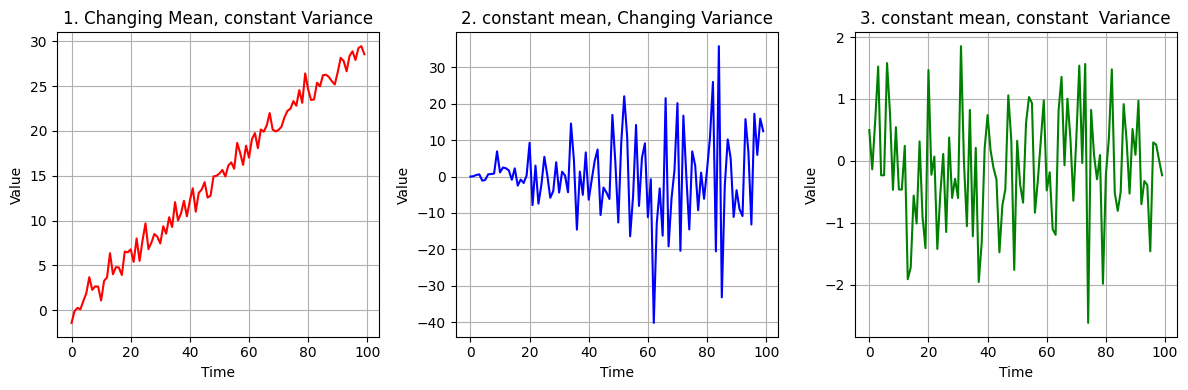

if the original time series is not stationary then,\
we create series by taking consecutive values of original time series\
then this new series check whether stationary or not\
if not, then second level of differencing is done and the process is continue.

#

#
## 🔰AD Fuller test🔰


is used to check wherther the time series is stationary or not̸  \
H0 in this case is that the time series is not stationary

In [184]:
from statsmodels.tsa.api import adfuller

In [185]:
adfuller(df_train)

(np.float64(0.2017160479163269),
 np.float64(0.9723576777571017),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(322.55907506392055))

In [186]:
df_train1 = df.diff()

In [187]:
df_train1.head(3)

,BirthRate
0,NaN
1,-3.065
2,3.333


In [188]:
df_train1 = df_train1.dropna() # 1st vlue is null thats why we are dropping null

In [189]:
adfuller(df_train1)

(np.float64(-4.495978986697214),
 np.float64(0.0001999559215388112),
 14,
 152,
 {'1%': np.float64(-3.474120870218417),
  '5%': np.float64(-2.880749791423677),
  '10%': np.float64(-2.5770126333102494)},
 np.float64(379.4527238223557))

<Axes: >

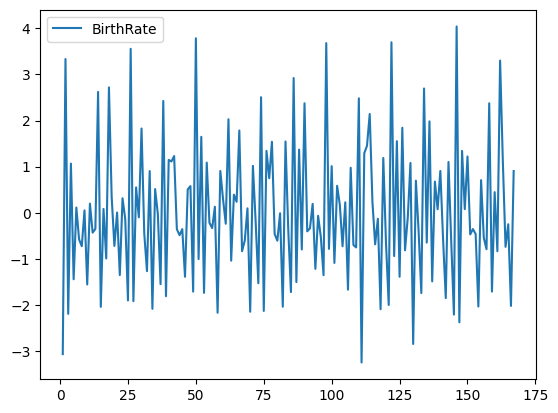

In [190]:
df_train1.plot()

# 🔰 Autocorrelation (ACF) 🔰

## What is Autocorrelation?

Autocorrelation is the correlation between a time series and its own past values (lags).

It helps us understand whether previous observations influence the current observation.

---

## Lag Concept

A **lag** represents a previous time step.

- Lag-0 → Current value
- Lag-1 → Previous value
- Lag-2 → Value from 2 time steps ago
- Lag-3 → Value from 3 time steps ago

---

## Example

| Time | Sales | Lag-0 | Lag-1 | Lag-2 | Lag-3 |
|------|--------|--------|--------|--------|--------|
| 1 | 5 | 5 | | | |
| 2 | 6 | 6 | 5 | | |
| 3 | 9 | 9 | 6 | 5 | |
| 4 | 4 | 4 | 9 | 6 | 5 |
| 5 | 7 | 7 | 4 | 9 | 6 |
| 6 | 6 | 6 | 7 | 4 | 9 |
| 7 | 8 | 8 | 6 | 7 | 4 |

---

## Interpretation

For Time = 5:

- Current Sales (Lag-0) = 7
- Lag-1 = 4
- Lag-2 = 9
- Lag-3 = 6

This means the current value can be compared with previous values to measure correlation.

---

## Why is Autocorrelation Important?

- Identifies patterns in time series data.
- Helps determine whether past values affect current values.
- Used in AR (AutoRegressive) models.
- Used in ARIMA model parameter selection.
- Visualized using the ACF (Autocorrelation Function) plot.

---

## ACF (Autocorrelation Function)

ACF measures the correlation between:

Current Value ↔ Lag-1

Current Value ↔ Lag-2

Current Value ↔ Lag-3

and so on.

---

## Key Points

✅ High positive autocorrelation → Strong relationship with past values

✅ Autocorrelation close to 0 → No relationship with past values

✅ Negative autocorrelation → Opposite relationship with past values

✅ Used extensively in ARIMA modeling

In [191]:
df_train.diff().dropna()

,BirthRate
1,-3.065
2,3.333
3,-2.191
4,1.066
5,-1.442
...,...
139,0.076
140,0.907
141,-0.564
142,-1.850


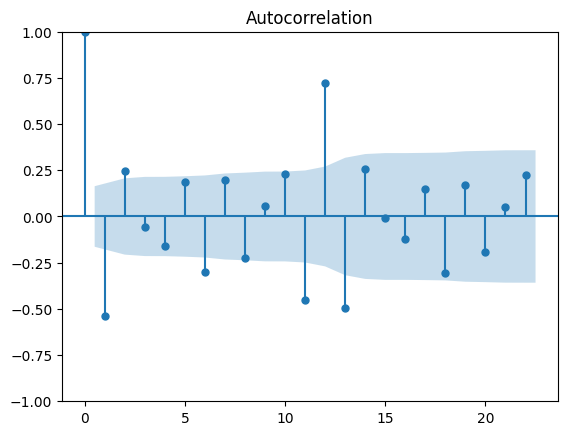

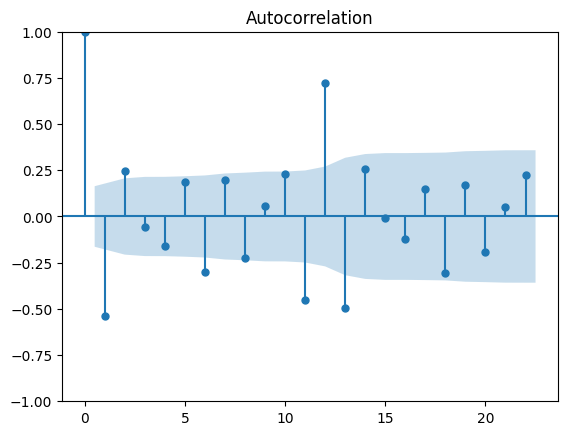

In [192]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_train.diff().dropna())  # gives the value of q which is the third number in the order



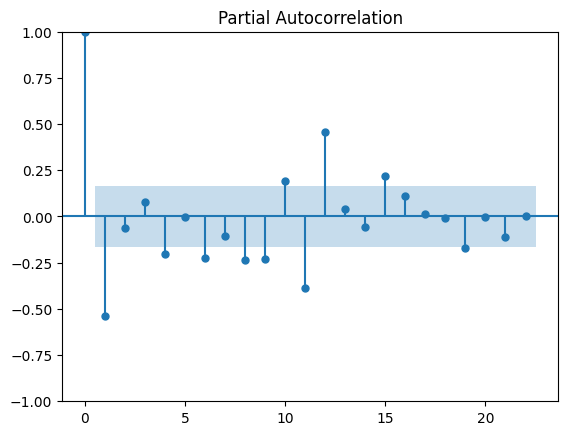

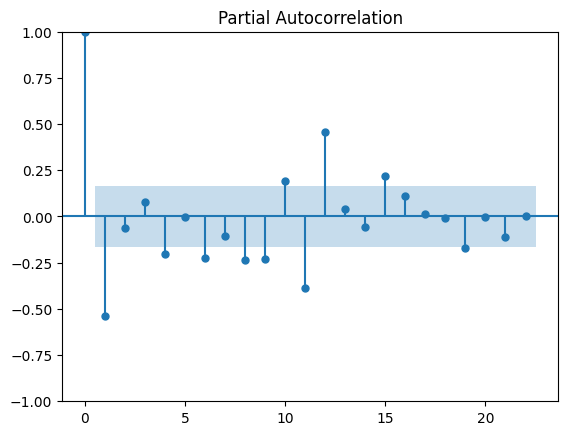

In [193]:
plot_pacf(df_train.diff().dropna()) # gives the value of p which is the first number in the order
# the second number in the order is d which is the number of times the differencing is applied to make a time series stationary
